In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [32]:
filepath = "../data/ML_spotify_data.csv"

In [33]:
spotify = pd.read_csv(filepath)
spotify

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo,cluster,cluster_name
0,We're For The Dark - Remastered 2010,['Badfinger'],22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674,3,Workout
1,Sixty Years On - Piano Demo,['Elton John'],25,0.456,0.259,0.368,0,6,0.1560,-10.692,0.0280,143.783,3,Workout
2,Got to Find Another Way,['The Guess Who'],21,0.433,0.833,0.724,0,0,0.1700,-9.803,0.0378,84.341,2,Chill
3,Feelin' Alright - Live At The Fillmore East/1970,['Joe Cocker'],22,0.436,0.870,0.914,0,5,0.8550,-6.955,0.0610,174.005,0,Balanced
4,Caravan - Take 7,['Van Morrison'],23,0.669,0.564,0.412,0,7,0.4010,-13.095,0.0679,78.716,3,Workout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,China,"['Anuel AA', 'Daddy Yankee', 'KAROL G', 'Ozuna...",72,0.786,0.608,0.808,0,7,0.0822,-3.702,0.0881,105.029,2,Chill
9996,Halloweenie III: Seven Days,['Ashnikko'],68,0.717,0.734,0.753,0,7,0.1010,-6.020,0.0605,137.936,2,Chill
9997,AYA,['MAMAMOO'],76,0.634,0.637,0.858,0,4,0.2580,-2.226,0.0809,91.688,2,Chill
9998,Darkness,['Eminem'],70,0.671,0.195,0.623,1,2,0.6430,-7.161,0.3080,75.055,4,Energetic


## 1. EDA

In [34]:
spotify.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          10000 non-null  str    
 1   artists       10000 non-null  str    
 2   popularity    10000 non-null  int64  
 3   danceability  10000 non-null  float64
 4   valence       10000 non-null  float64
 5   energy        10000 non-null  float64
 6   explicit      10000 non-null  int64  
 7   key           10000 non-null  int64  
 8   liveness      10000 non-null  float64
 9   loudness      10000 non-null  float64
 10  speechiness   10000 non-null  float64
 11  tempo         10000 non-null  float64
 12  cluster       10000 non-null  int64  
 13  cluster_name  10000 non-null  str    
dtypes: float64(7), int64(4), str(3)
memory usage: 1.5 MB


In [35]:
spotify.describe()

,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo,cluster
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,37.556800,0.549507,0.523148,0.592609,0.103200,5.20560,0.209787,-9.822324,0.081426,120.179723,2.192800
std,12.559743,0.178097,0.261456,0.251808,0.304235,3.56205,0.193693,5.321064,0.100472,30.260748,1.319016
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,-60.000000,0.000000,0.000000,0.000000
25%,27.000000,0.430000,0.313000,0.414000,0.000000,2.00000,0.093900,-12.347250,0.034200,96.191250,1.000000
50%,36.000000,0.557000,0.524500,0.616000,0.000000,5.00000,0.129000,-8.762000,0.045100,118.330500,2.000000
75%,46.000000,0.681000,0.742000,0.801000,0.000000,9.00000,0.261250,-6.070750,0.077400,139.609500,3.000000
max,86.000000,0.986000,0.996000,1.000000,1.000000,11.00000,1.000000,1.073000,0.957000,224.437000,4.000000


The dataset contains 10 000 tracks with no missing values, making it is suitable for clustering without additional data cleaning. Most features are normalised within a 0-1 range, while other (e.g. popularity, key, and tempo) operate on different scales. This variation in scale indicates the need for feature standardisation before applying clustering algorithms.

array([[<Axes: title={'center': 'popularity'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'valence'}>],
       [<Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'explicit'}>,
        <Axes: title={'center': 'key'}>],
       [<Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'tempo'}>]], dtype=object)

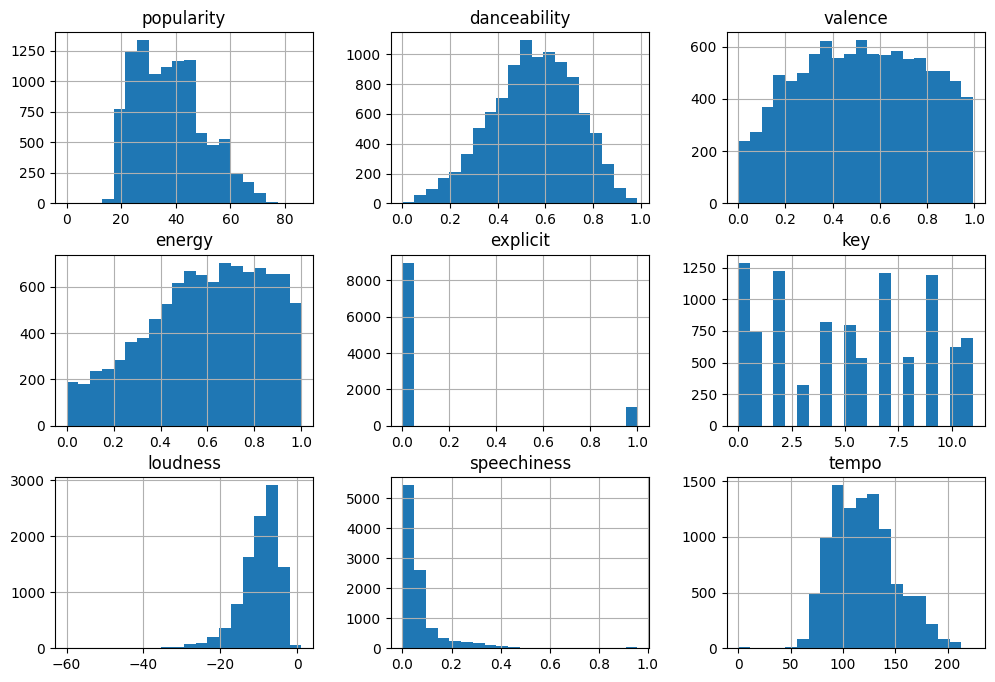

In [36]:
features = ['popularity', 'danceability', 'valence','energy', 'explicit', 'key', 'loudness', 'speechiness', 'tempo']
spotify[features].hist(bins=20, figsize=(12,8))

The distribution of feature values provides useful insight into the dataset.

*   Danceabality and energy are slightly skewed towards higher values, suggesting that there are more upbeat, energetic songs in the dataset.
*   Loudness is concentrated within a relatively narrow range and also skewed toward higher values.
*   Valence is widely distributed, indicating a mix of melancholic and positive tracks.
*   Tempo is relatively evenly distributed, although with a longer tail towards higher values.
*   Speechiness is strongly skewed toward lower values, suggesting that most tracks are music rather than spoken-word content.
*   The explicit feature is binary and highly imbalanced, with the majority of tracks being non-explicit, which may limit its usefulness in clustering.

Additionally, the key feature represents categorical musical information encoded numerically, which may not be well-suited for distance-based methods such as K-Means.

<Axes: >

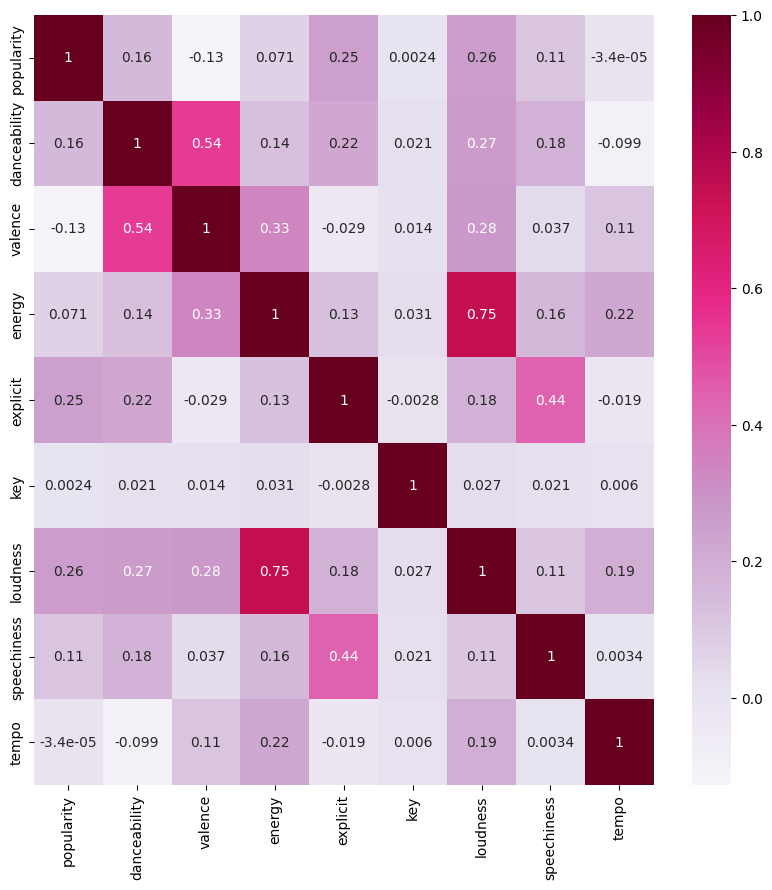

In [37]:
plt.figure(figsize=(10,10))
sns.heatmap(spotify[features].corr(), annot=True, cmap='PuRd')

The correlation analysis reveals a strong relationship between energy and loudness (0.75), which is expected as louder tracks tend to be more energetic. There is a moderate correlation between valence and danceability (0.54), suggesting that more positive songs are often more danceable. Additionally, speechiness shows some correlation with explicit content, which may reflect certain genres (e.g. hip-hop). These relationships indicate potential redundancy between features, which is important to consider during clustering.

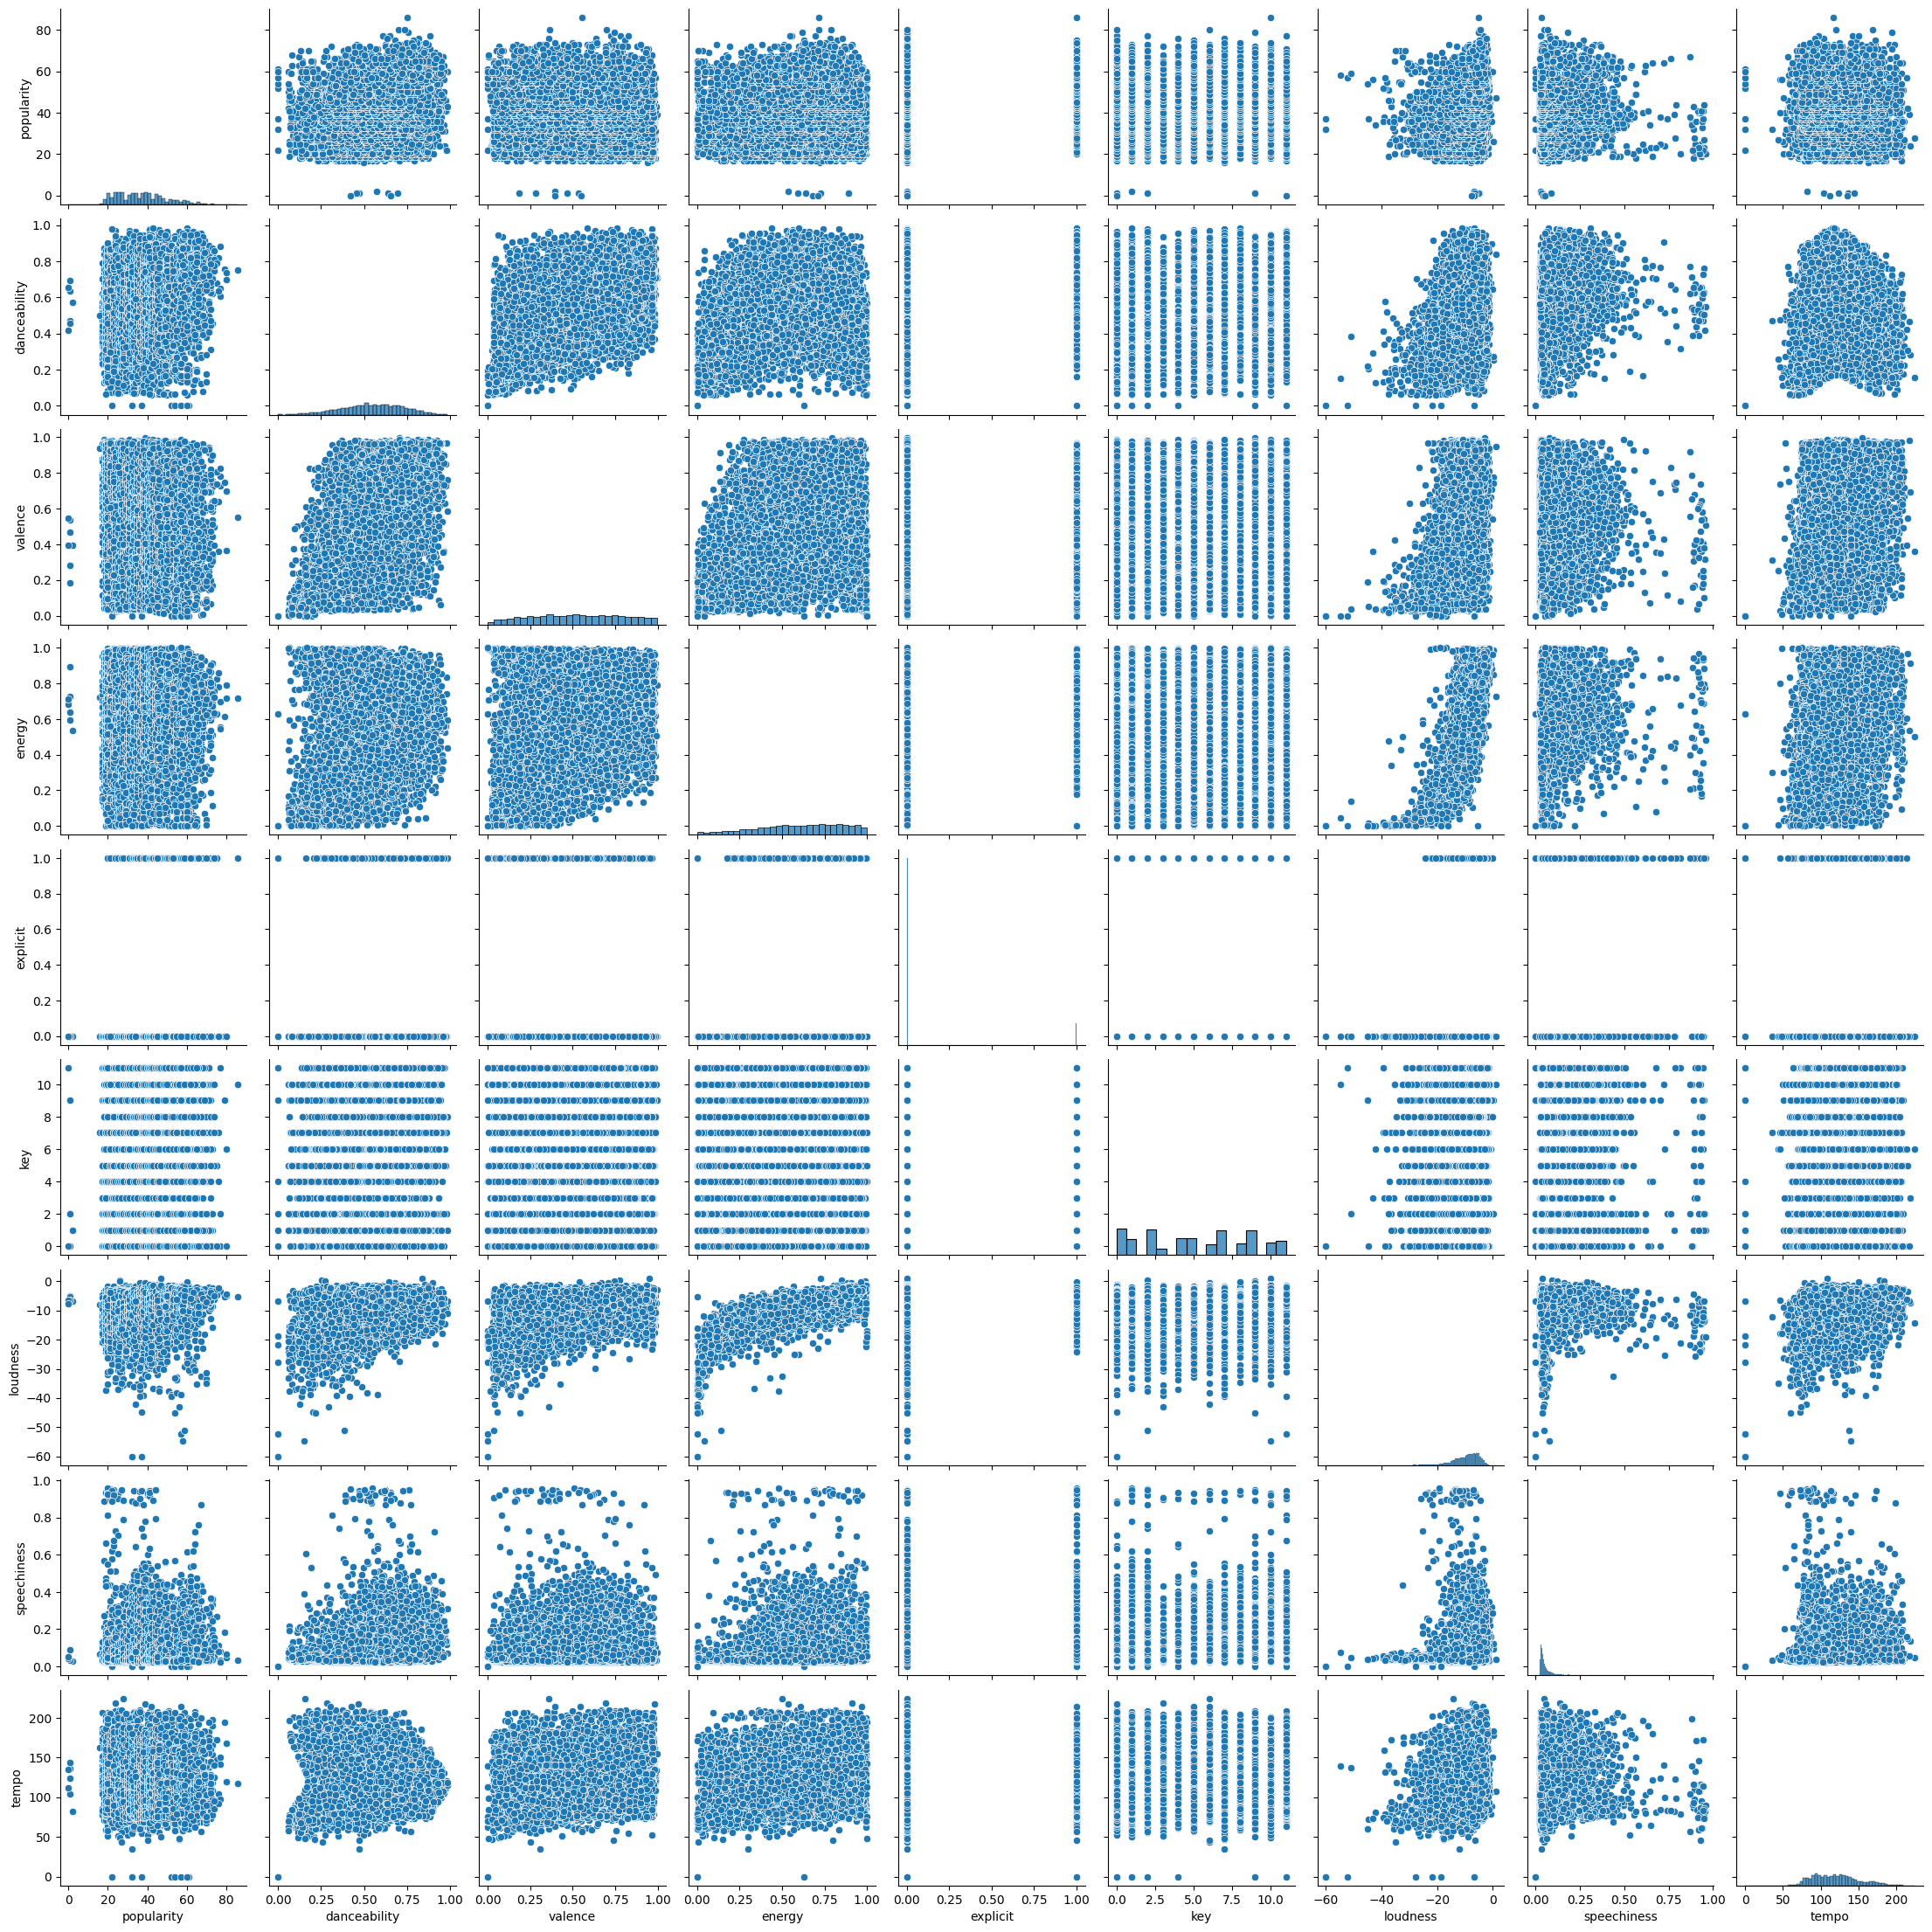

In [38]:
sns.pairplot(spotify[features])

The pairplot provides a visual confirmation of relationships between features and helps identify potential clustering patterns.
A clear relationship can be observed between energy and loudness, which is consistent with the earlier correlation analysis.
While the correlation matrix indicates a moderate relationship between valence and danceability, this dependency is not strongly visible in the pairplot, suggesting that it is relatively weak or dispersed.
Overall, relationships between most feature pairs appear continuous rather than clearly separable, indicating that natural groupings in the data are subtle rather than well-defined.
Additionally, features such as key and explicit appear as discrete or binary variables, which may limit their usefulness in distance-based clustering methods like K-Means.
In contrast, features like loudness show more structured patterns and are likely to carry meaningful information for clustering, whereas others, such as speechiness, may primarily help identify niche or edge cases.
Overall, the absence of clear cluster boundaries suggests that clustering results will depend heavily on feature scaling, selection, and algorithm choice.

Based on the exploratory analysis, the next step is to select relevant numerical features, apply standardisation, and proceed with clustering while accounting for feature redundancy and scale differences.

## 2. Feature selection & normalisation

Based on the exploratory data analysis, a subset of numerical features was selected for clustering.
Features such as **danceability**, **energy**, **valence**, **loudness**, and **tempo** were retained as they capture continuous characteristics of music and show meaningful variation across tracks.
In contrast, features like key and explicit were excluded, as they represent categorical or highly imbalanced variables, which are less suitable for clustering methods like K-Means.
Speechiness was considered but treated cautiously, as it is heavily skewed and primarily useful for identifying niche cases rather than broad patterns.
Popularity was not included in the clustering step, as it reflects user behaviour rather than intrinsic audio characteristics. Instead, it was incorporated in the recommendation layer to rank songs within each cluster, balancing audio similarity with real-world relevance.
Due to differences in feature scales, standardisation was applied to ensure that all features contribute equally to the clustering process.

In [39]:
features = ['danceability', 'energy', 'valence', 'loudness', 'tempo']
spotify_selected = spotify[features]
spotify_selected

,danceability,energy,valence,loudness,tempo
0,0.678,0.432,0.559,-12.696,117.674
1,0.456,0.368,0.259,-10.692,143.783
2,0.433,0.724,0.833,-9.803,84.341
3,0.436,0.914,0.870,-6.955,174.005
4,0.669,0.412,0.564,-13.095,78.716
...,...,...,...,...,...
9995,0.786,0.808,0.608,-3.702,105.029
9996,0.717,0.753,0.734,-6.020,137.936
9997,0.634,0.858,0.637,-2.226,91.688
9998,0.671,0.623,0.195,-7.161,75.055


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
spotify_scaled = scaler.fit_transform(spotify_selected)
spotify_scaled

,danceability,energy,valence,loudness,tempo
0,0.721511,-0.637854,0.137131,-0.540084,-0.082809
1,-0.525061,-0.892028,-1.010349,-0.163448,0.780035
2,-0.654211,0.521816,1.185161,0.003632,-1.184390
3,-0.637365,1.276395,1.326684,0.538890,1.778805
4,0.670974,-0.717283,0.156255,-0.615072,-1.370283
...,...,...,...,...,...
9995,1.327952,0.855420,0.324552,1.150264,-0.500697
9996,0.940504,0.636989,0.806493,0.714615,0.586805
9997,0.474443,1.053993,0.435475,1.427666,-0.941588
9998,0.682205,0.120697,-1.255144,0.500174,-1.491271


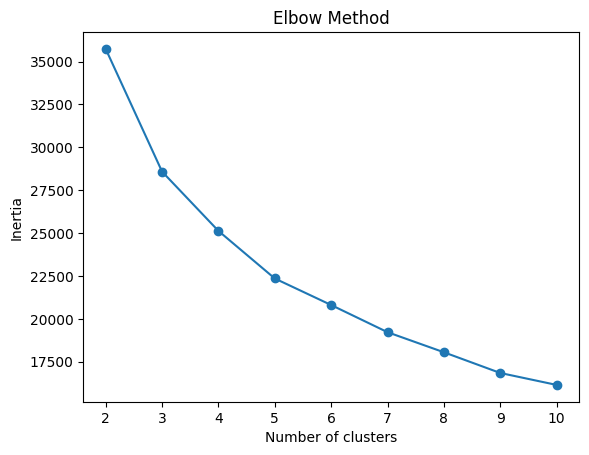

In [41]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(spotify_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

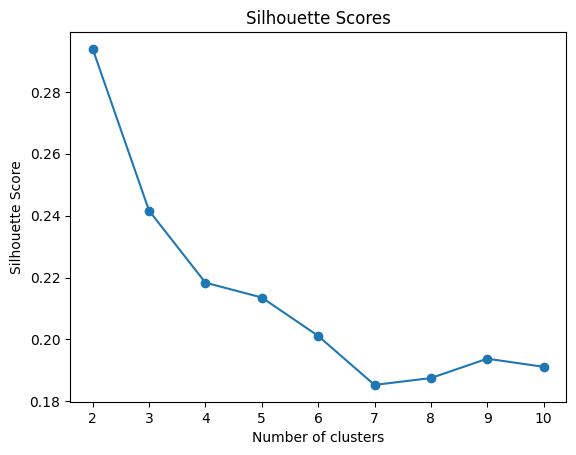

In [42]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(spotify_scaled)
    sil_scores.append(silhouette_score(spotify_scaled, labels))

plt.plot(k_range, sil_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

The elbow method suggests an optimal range between 4 and 6 clusters, where the rate of improvement begins to slow.
Although the silhouette score is highest for k = 2, this would result in overly broad groupings that are not meaningful for recommendation purposes.
Therefore, k = 5 was selected as a balance between cluster quality and interpretability, allowing for more nuanced segmentation of music styles.

## 3. Cluster interpretation

In [43]:
kmeans = KMeans( n_clusters = 5, random_state = 15)
kmeans.fit(spotify_scaled)
px.scatter_3d(spotify_scaled, x = "danceability", y = "energy", z = "valence", color = kmeans.labels_)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': ('danceability=%{x}<br>energy=%{' ... '%{marker.color}<extra></extra>'),
              'legendgroup': '',
              'marker': {'color': {'bdata': ('AwAAAAMAAAAAAAAABAAAAAMAAAADAA' ... 'AAAAAAAAAAAAAAAAABAAAAAAAAAA=='),
                                   'dtype': 'i4'},
                         'coloraxis': 'coloraxis',
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'scene': 'scene',
              'showlegend': False,
              'type': 'scatter3d',
              'x': {'bdata': ('ATNPiJ4W5z8UQeMvTc3gv2GL/xVL7+' ... 'EaRV3eP3rOAyyf1OU/npfBIkeJ+z8='),
                    'dtype': 'f8'},
              'y': {'bdata': ('6c1xaExp5L+6xb1Nfovsv6zMuD23su' ... 'faJ93wP9FM5/4D5r4/Cz355hxR4D8='),
                    'dtype': 'f8'},
              'z': {'bdata': ('MBd2PX6NwT8wX2I/Yyrwv63SQdNr9v' ... 'Po0t7bP4A9NvkRFfS/3Ry2gikY3T8='),
                    'dtype': 'f8'}}],
    'layout': {'coloraxis': {'colorbar': {'title': {'text': 'color'}},
                             'colorscale': [[0.0, '#0d0887'], [0.1111111111111111,
                                            '#46039f'], [0.2222222222222222,
                                            '#7201a8'], [0.3333333333333333,
                                            '#9c179e'], [0.4444444444444444,
                                            '#bd3786'], [0.5555555555555556,
                                            '#d8576b'], [0.6666666666666666,
                                            '#ed7953'], [0.7777777777777778,
                                            '#fb9f3a'], [0.8888888888888888,
                                            '#fdca26'], [1.0, '#f0f921']]},
               'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'scene': {'domain': {'x': [0.0, 1.0], 'y': [0.0, 1.0]},
                         'xaxis': {'title': {'text': 'danceability'}},
                         'yaxis': {'title': {'text': 'energy'}},
                         'zaxis': {'title': {'text': 'valence'}}},
               'template': '...'}
})

K-Means clustering was applied to the standardised feature set to group songs based on their audio characteristics.Each song was assigned to a cluster, representing a group of tracks with similar musical properties.

In [44]:
spotify['cluster'] = kmeans.fit_predict(spotify_scaled)
features = ['danceability', 'energy', 'valence', 'loudness', 'tempo']
cluster_summary = spotify.groupby('cluster')[features].mean()
cluster_summary

,danceability,energy,valence,loudness,tempo
cluster,,,,,
0,0.710627,0.680230,0.768505,-8.186429,113.023216
1,0.471879,0.786765,0.367703,-6.522558,111.605941
2,0.303963,0.157359,0.167712,-20.689579,103.781122
3,0.568298,0.374680,0.418022,-12.218161,109.382227
4,0.453473,0.724642,0.583074,-7.702387,165.572001


In [45]:
cluster_names = {
    0: "Party",
    1: "Workout",
    2: "Chill",
    3: "Balanced",
    4: "Energetic"
}

spotify['cluster_name'] = spotify['cluster'].map(cluster_names)

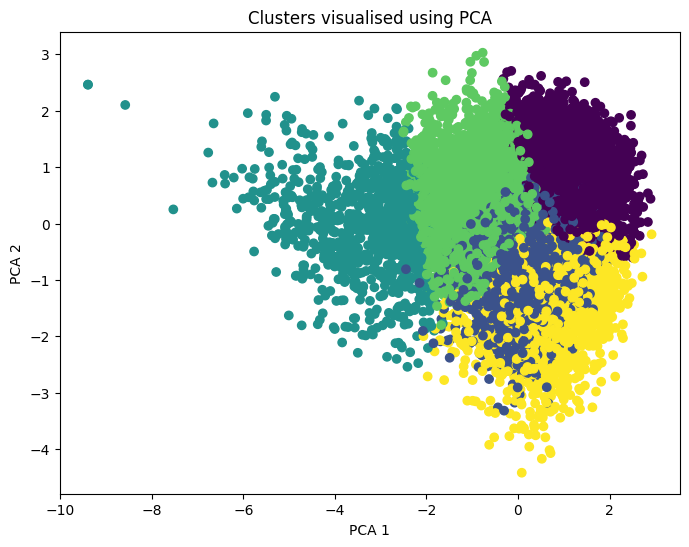

In [46]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(spotify_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=spotify['cluster'])
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters visualised using PCA')
plt.show()

The resulting clusters were analysed by examining the average feature values within each group. Distinct patterns emerged, allowing clusters to be interpreted as different listening profiles. For example, the Chill cluster contains low-energy, low-valence tracks, while the Party cluster groups highly danceable and positive songs. Similarly, the Workout cluster is characterised by high tempo and energy, making it suitable for high-intensity activities.

## Recommendation function

In [47]:
from sklearn.metrics.pairwise import cosine_similarity

spotify.reset_index(drop=True, inplace=True)
spotify_scaled.reset_index(drop=True, inplace=True)

def recommend_similar(song_name, n_rec=5):

    song_idx = spotify[spotify['name'] == song_name].index

    if len(song_idx) == 0:
        return "Song not found"

    song_idx = int(song_idx[0])

    song_vector = spotify_scaled.iloc[[song_idx]]

    similarities = cosine_similarity(song_vector, spotify_scaled)[0]

    recommendations = spotify.copy()
    recommendations['similarity'] = similarities

    cluster = spotify.iloc[song_idx]['cluster']
    recommendations = recommendations[recommendations['cluster'] == cluster]
    recommendations = recommendations[recommendations.index != song_idx]

    recommendations = recommendations.sort_values(by='similarity', ascending=False)

    return recommendations[['name', 'artists', 'cluster_name', 'popularity', 'similarity']].head(n_rec)

In [48]:
recommend_similar("New Rules")

,name,artists,cluster_name,popularity,similarity
7527,Shawty Get Loose (feat. Chris Brown & T-Pain),"['Lil Mama', 'Chris Brown', 'T-Pain']",Party,43,0.996091
9565,Take Me Away,['Scotty Sire'],Party,59,0.995988
7104,Bendita Tu Luz,['Maná'],Party,49,0.990219
8134,Revolting Children,['Matilda the Musical Original Cast'],Party,51,0.988582
8639,Trouble,"['Iggy Azalea', 'Jennifer Hudson']",Party,47,0.985041


A hybrid recommendation approach was implemented by combining clustering and cosine similarity. First, songs are filtered within the same cluster to ensure a consistent musical vibe. Then, cosine similarity is used to identify the most similar tracks within that group. Finally, results are ranked by similarity and popularity, balancing precision with real-world relevance.